Total trials: 30
Labels distribution: [6 6 6 6 6]
Channels: 8, Time points per trial: 350
Estimated sampling rate: 291.7 Hz



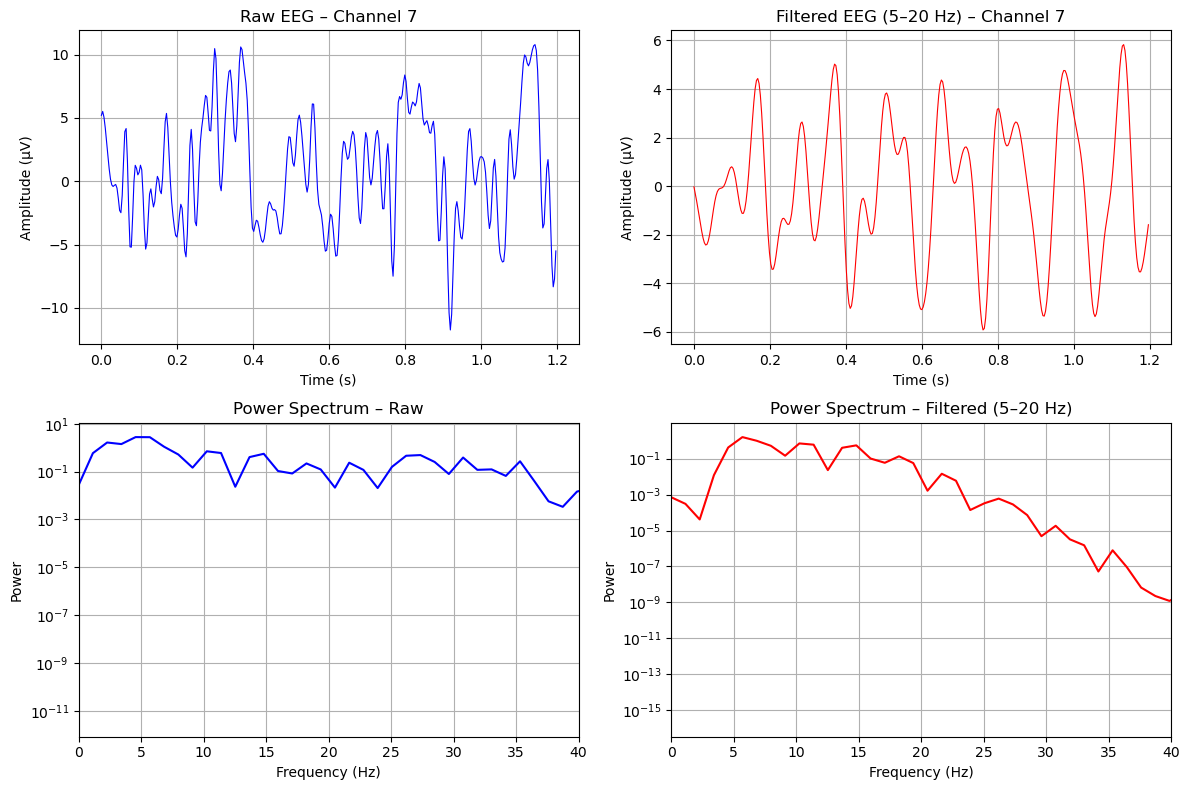

BEST RESULT: 5–20 Hz BANDPASS FILTER + LOGISTIC REGRESSION
____________________________________________________________
5–20 Hz filter Accuracy: 40.00%
  Class 0: 16.67%
  Class 1: 66.67%
  Class 2: 33.33%
  Class 3: 50.00%
  Class 4: 33.33%
  Permutation p-value: 0.0140


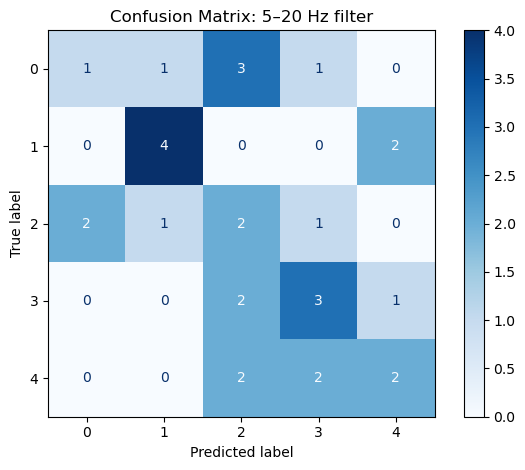

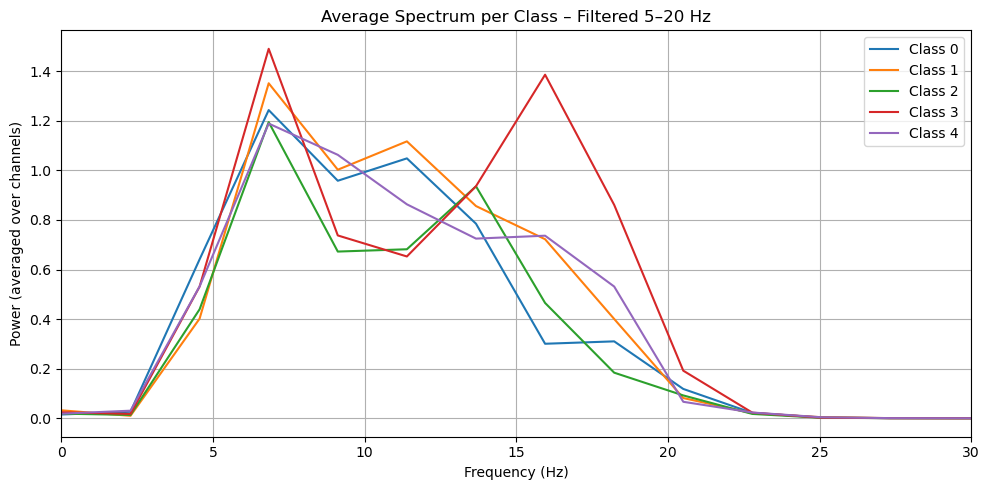

In [35]:
"""
SSVEP Data Analysis + Pre/Post Filter Demo
COGS 189 Project – Aviators

This script:
- Loads all three calibration runs.
- Plots raw and filtered (5-20 Hz) EEG for a sample trial to show filter effect.
- Runs the best analysis: 5-20 Hz filter, power spectral features, logistic regression,
  5-fold cross-validation, permutation test, confusion matrix, and average spectra.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, butter, filtfilt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict, permutation_test_score
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import os


# 1. LOAD ALL CALIBRATION RUNS
base_path = os.path.join('data_unzipped', 'calibration runs',
                         'cyton8_rocket-vep_5-class_1.2s')
runs = ['run-1', 'run-2', 'run-3']

all_eeg = []
all_labels = []

for run in runs:
    run_path = os.path.join(base_path, run)
    eeg = np.load(os.path.join(run_path, 'eeg_trials.npy'), allow_pickle=True)
    labels = np.load(os.path.join(run_path, 'labels.npy'), allow_pickle=True)
    all_eeg.extend(eeg)
    all_labels.extend(labels)

all_eeg = np.array(all_eeg, dtype=object)
all_labels = np.array(all_labels)
print(f"Total trials: {len(all_eeg)}")
print(f"Labels distribution: {np.bincount(all_labels)}")

# Get dimensions from first trial
trial0 = all_eeg[0]
n_channels, n_times = trial0.shape
sfreq = n_times / 1.2                     # trial duration = 1.2 s
print(f"Channels: {n_channels}, Time points per trial: {n_times}")
print(f"Estimated sampling rate: {sfreq:.1f} Hz\n")


# 2. DEMO: RAW vs FILTERED EEG FOR A SINGLE TRIAL
# Use first trial from run-1 as an example
demo_trial_path = os.path.join(base_path, 'run-1', 'eeg_trials.npy')
demo_eeg = np.load(demo_trial_path, allow_pickle=True)[0]   # first trial
demo_data = np.real(demo_eeg).astype(float)

# Choose an occipital channel (adjust index if you know a better one)
channel_idx = 7   # 0-indexed, often the last channel
raw_signal = demo_data[channel_idx, :]

# Design 5-20 Hz bandpass filter
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data)
    return y

filtered_signal = bandpass_filter(raw_signal, lowcut=5, highcut=20, fs=sfreq)

# Time vector
time = np.arange(n_times) / sfreq

# Plot time domain
plt.figure(figsize=(12, 8))

plt.subplot(2,2,1)
plt.plot(time, raw_signal, 'b-', linewidth=0.8)
plt.title(f'Raw EEG – Channel {channel_idx}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.grid(True)

plt.subplot(2,2,2)
plt.plot(time, filtered_signal, 'r-', linewidth=0.8)
plt.title(f'Filtered EEG (5–20 Hz) – Channel {channel_idx}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.grid(True)

# Frequency domain
f_raw, Pxx_raw = welch(raw_signal, fs=sfreq, nperseg=min(256, n_times))
f_filt, Pxx_filt = welch(filtered_signal, fs=sfreq, nperseg=min(256, n_times))

plt.subplot(2,2,3)
plt.semilogy(f_raw, Pxx_raw, 'b-')
plt.xlim(0, 40)
plt.title('Power Spectrum – Raw')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.grid(True)

plt.subplot(2,2,4)
plt.semilogy(f_filt, Pxx_filt, 'r-')
plt.xlim(0, 40)
plt.title('Power Spectrum – Filtered (5–20 Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.grid(True)

plt.tight_layout()
plt.show()


# 3. HELPER FUNCTIONS FOR ANALYSIS
def bandpass_filter_trial(data, lowcut, highcut, fs=sfreq):
    """Apply zero-phase bandpass filter to data (channels × time)."""
    b, a = butter_bandpass(lowcut, highcut, fs, order=4)
    y = filtfilt(b, a, data, axis=1)
    return y

def extract_features(eeg_list, lowcut, highcut):
    """
    Filter each trial with lowcut–highcut bandpass, then compute power spectra
    for all channels and concatenate into a feature vector.
    Returns: feature matrix (trials, n_channels * n_freqs), frequency array.
    """
    freqs = None
    features = []
    for trial in eeg_list:
        # Convert to real float and filter
        trial_data = np.real(trial).astype(float)
        trial_data = bandpass_filter_trial(trial_data, lowcut, highcut)
        trial_feat = []
        for ch in range(n_channels):
            f, Pxx = welch(trial_data[ch, :], fs=sfreq, nperseg=min(128, n_times))
            if freqs is None:
                freqs = f
            trial_feat.append(Pxx)
        features.append(np.concatenate(trial_feat))
    return np.array(features), freqs

def evaluate(X, y, title):
    """Run cross-validated classification and print results."""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    clf = LogisticRegression(max_iter=1000, random_state=42)

    # Cross-validated predictions
    y_pred = cross_val_predict(clf, X_scaled, y, cv=cv)
    acc = accuracy_score(y, y_pred)
    print(f"{title} Accuracy: {acc*100:.2f}%")
    for c in np.unique(y):
        mask = y == c
        acc_c = np.mean(y_pred[mask] == c)
        print(f"  Class {c}: {acc_c*100:.2f}%")

    # Permutation test for significance
    score, perm_scores, pvalue = permutation_test_score(
        clf, X_scaled, y, cv=cv, n_permutations=500, random_state=42, scoring='accuracy'
    )
    print(f"  Permutation p-value: {pvalue:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix: {title}')
    plt.tight_layout()
    plt.show()
    return acc, pvalue


# 4. RUN THE BEST ANALYSIS (5–20 Hz FILTER)

print("BEST RESULT: 5–20 Hz BANDPASS FILTER + LOGISTIC REGRESSION")
print("_"*60)
X_best, freqs = extract_features(all_eeg, lowcut=5, highcut=20)
acc_best, p_best = evaluate(X_best, all_labels, "5–20 Hz filter")


# 5. PLOT AVERAGE SPECTRA (FILTERED)
# Compute average spectrum per class after filtering
avg_spec = []
for c in range(5):
    class_trials = all_eeg[all_labels == c]
    spec = []
    for trial in class_trials:
        data = np.real(trial).astype(float)
        data_filt = bandpass_filter_trial(data, 5, 20)
        # Average over channels for a summary spectrum
        avg_ch = data_filt.mean(axis=0)
        f, Pxx = welch(avg_ch, fs=sfreq, nperseg=128)
        spec.append(Pxx)
    avg_spec.append(np.mean(spec, axis=0))

plt.figure(figsize=(10,5))
for i in range(5):
    plt.plot(f, avg_spec[i], label=f'Class {i}')
plt.xlim(0, 30)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (averaged over channels)')
plt.title('Average Spectrum per Class – Filtered 5–20 Hz')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()